In [331]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
print("Libraries loaded successfully")

Libraries loaded successfully


# Churn definition
churn analysis is a process of figuring out why customers stop doing bussiness with you.

for this, we only look at three things :

1. "who" : identifyng which customer left or will leave in future .

2. "why":  analyzing their behaviour before they left

3. "when":  finding the danger zone point when a user leave.


 ## bussiness type             /       churn definition

 SaaS                         /    subscription canceled 
 E-commerce                  /      nopurchase in 90 days 
 adtech                      /    using service in 90-120 days
 streaming                  /    memberhsip inactive 
 telecom                    /   account terminated 
 banking                   /   no transactions for x month
 

In [332]:
###  1. import data base

conn = sqlite3.connect("customer_churn.db")

sql_query="""
      SELECT name
      FROM sqlite_master
      WHERE type='table'
"""


tables = pd.read_sql(sql_query,conn)

## create dataframe for each table 

for table_name in tables['name']:
    df=pd.read_sql( f"SELECT * FROM {table_name}" , conn)
    globals()[f"df_{table_name}"] = df 
    print(f"created dataframes: df_{table_name}")


conn.close()

    

created dataframes: df_db_customer
created dataframes: df_db_subscription
created dataframes: df_db_support


In [333]:
## print table names and columns name 

conn = sqlite3.connect("customer_churn.db")


for table in tables["name"]:
    print(f"/ntable name:{table_name}")

    columns_query= f"PRAGMA table_info({table_name})"
    columns=pd.read_sql(columns_query, conn )

    print("columns:")
    print(columns['name'].tolist())


conn.close()    

/ntable name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']
/ntable name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']
/ntable name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [334]:
### 2. data cleaning 

df_db_customer.head()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [335]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [336]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


# to do list for data cleaning

1. rename col_name
2. drop columns interst and pincode
3. change data type of dob 
4. data standardization -gender 
5. fixing missing values in column country 


In [337]:
## 1. rename col_name

df_db_customer.rename(columns= {"name" : " customer_name"}, inplace=True)

df_db_customer


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [338]:
### 2. drop columns interst and pincode

# df_db_customer.drop(df_db_customer.columns[-2:]  , axis=1 )

df_db_customer.drop(columns=['interests','pincode'] , inplace=True )

In [339]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [340]:
## 3. change data type of dob 
df_db_customer['dob']= pd.to_datetime(df_db_customer['dob'])

In [341]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [342]:
## 4. data standardization -gender
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [343]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male', 'Women':'Female'})

In [344]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [345]:
### 5. fix missing values -cou
df_db_customer['country'].isnull()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [346]:
## giving us values only which are null

df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [347]:
df_db_customer['country'].fillna('dont know')

0         India
1         India
2         India
3         India
4         India
5     dont know
6         India
7         India
8     dont know
9         Nepal
10        India
11        India
12    dont know
13        India
14        India
15        India
16        India
17        India
18        India
19        India
20        India
Name: country, dtype: str

In [348]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [349]:
## country and state unique value pair
df_db_customer.dropna(subset=['country']).set_index('state')

,customerid,customer_name,country,gender,dob
state,,,,,
Maharashtra,0002-ORFBO,keshav,India,Male,1982-04-12
Karnataka,0003-MKNFE,raghav,India,Male,1995-11-23
Delhi,0004-TLHLJ,lalita,India,Female,1978-02-15
Nagaland,0011-IGKFF,mohan,India,Male,2001-08-30
Delhi,0013-EXCHZ,mira,India,Female,1990-05-05
Meghalaya,0013-SMEOE,mina,India,Female,1976-09-21
Rajasthan,0014-BMAQU,madan,India,Male,1999-03-14
Kathmandu,0016-QLJIS,arjun,Nepal,Male,1993-10-29
Maharashtra,0017-DINOC,shiva,India,Male,1997-01-22


In [350]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [351]:
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [352]:
df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping)
)

In [353]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [354]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob


# 2ns table db_subscription


In [355]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [356]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [357]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime, errors='coerce')

In [358]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [359]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [360]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [361]:
df_db_support.drop(columns=['col_1','comment'], inplace=True)

In [362]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [363]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [364]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


# feature engineering and data analyst

In [365]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34


In [366]:
## createing new column


df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [367]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0


In [368]:
df_db_subscription.merge(df_db_customer , on='customerid', how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [369]:
df=(df_db_subscription
    .merge(df_db_customer , on='customerid', how='left')
    .merge(df_db_support , on='customerid', how='left'))

In [370]:
df_db_subscription.shape

(21, 12)

In [371]:
df.shape

(23, 20)

In [372]:
df_db_subscription['customerid'].nunique()

21

In [373]:
df_db_customer['customerid'].nunique()

21

In [374]:
df_db_support['customerid'].nunique()

7

In [375]:
df_db_support['customerid'].size

9

In [376]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [377]:
df_db_support.groupby('customerid')['customerid'].transform('count')

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: customerid, dtype: int64

In [378]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [379]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [380]:
df_db_support.sort_values('complaint_date')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [381]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates(subset='customerid', keep='last')


In [382]:
df_db_support


,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [383]:
## again merging db_support


df=(df_db_subscription
    .merge(df_db_customer , on='customerid', how='left')
    .merge(df_db_support , on='customerid', how='left'))

In [384]:
df.shape

(21, 21)

# data analysis

In [385]:
## creating csv file

df.to_csv('exported_churn_data.csv',index=False)

In [386]:
## churn rate

df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [387]:
churn_rate = df['churn_flag'].mean()*100

print("churn rate :",round(churn_rate,2),"%")

churn rate : 28.57 %


In [388]:
### retention rate

retention_rate= 100 - churn_rate
print("retention rate :",round(retention_rate,2),"%")

retention rate : 71.43 %


In [389]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [390]:
## churn by plan_type meaning which type of users gonna left our bussiness

churn_by_plan_type= df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index()

In [391]:
churn_by_plan_type

,plan_type,churn_flag
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [392]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [393]:
## churn_by state
## churn by subscription_type

In [394]:
churn_rate_state= df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index()

In [395]:
churn_rate_state

,state,churn_flag
0,Delhi,25.00
1,Karnataka,100.00
2,Kathmandu,0.00
3,Maharashtra,0.00
4,Meghalaya,66.67
5,Nagaland,0.00
6,Rajasthan,0.00
7,Telangana,50.00
8,Uttar Pradesh,0.00


In [396]:
churn_subscription_type= df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index()

In [397]:
churn_subscription_type

,subscription_type,churn_flag
0,Organic,0.00
1,Paid,16.67
2,Refferal,83.33


# ARPU - avg revenue per user

In [398]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [399]:
ARPU=df['monthly_charges'].mean()
print('ARPU:',ARPU)

ARPU: 18.847142857142856


In [400]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [401]:
## calculate customer age by using timestamp 

In [402]:
## now lets calculate how many days a customer took subscription of our bussiness
### avg customer tenure 
## if acustomer does not end subscription then we will calculate days from day one to today 

today=pd.Timestamp.today()

df['tenure_days']=np.where(
     df['cancellation_date'].notna(),

     (df['cancellation_date'] - df['subscription_start_date']).dt.days,
     (today-df['subscription_start_date']).dt.days
    
)

avg_tenure= df['tenure_days'].mean()

print('avg tenure:' , round(avg_tenure),0)


avg tenure: 1557 0


# calculating age of customers

In [403]:
today

Timestamp('2026-10-09 23:30:19.534848')

In [404]:
df['age'] = (today - df['dob']).dt.days / 365.25
df['age'].head()

0    44.492813
1    30.877481
2    48.646133
3    25.108830
4    36.429843
Name: age, dtype: float64

In [405]:
df['age'] = (
    today.year - df['dob'].dt.year
    - (
        (today.month < df['dob'].dt.month)
        | ((today.month == df['dob'].dt.month) & (today.day < df['dob'].dt.day))
    ).astype(int)
)
df['age'].head()

0    44
1    30
2    48
3    25
4    36
Name: age, dtype: int64

In [406]:
### revenue at risk or revenue lost from churned users
df.loc[df['churn_flag']==1,'monthly_charges']

1     12.99
4     13.99
6      8.99
11     7.99
13    12.99
18    16.99
Name: monthly_charges, dtype: float64

In [407]:
revnue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()

print("revenue at risk (rs 'k') = " , revnue_at_risk)

revenue at risk (rs 'k') =  73.94


In [408]:
## Escalation rate (raise problem at next level if problem is not solved and getting worse)

escalation_rate=(df['escalations']=='Y').mean()*100
print("Escalation rate :",round(escalation_rate,2),"%")

Escalation rate : 19.05 %


In [409]:
#avg complaint per user
avg_complain= df['complaint_count'].notna().mean() * 100 

print("avg complaint:",round(avg_complain,2),"%")

avg complaint: 33.33 %


In [410]:
## finding correlation escaltaion vs churn

df[['customerid','escalations','churn_flag']].dropna()


,customerid,escalations,churn_flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [411]:
## converting escalation  y n value to 0 and 1
# so that machine can understand it better


df['escalations']= np.where(df['escalations'] == 'Y',1,0) # encoding string to int type

corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("correlation between escalation and churn is:", round(correlation, 2))

correlation between escalation and churn is: 0.77


In [412]:
print(corr_df.dtypes)
print(corr_df['escalations'].value_counts())
print(corr_df['churn_flag'].value_counts())

escalations    int64
churn_flag     int64
dtype: object
escalations
0    17
1     4
Name: count, dtype: int64
churn_flag
0    15
1     6
Name: count, dtype: int64


In [413]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2034.0,44
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,30
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1419.0,48
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2709.0,25
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,36


In [414]:
### creating a column using existing column printing churn risk

from random import choice


conditions=[
           (df['churn_score'] < 50 ),
           (df['churn_score'] >=50) & (df['churn_score'] < 70),
           (df['churn_score'] >= 70)
]



choices=['low','med','high']

df['churn_risk'] = np.select(conditions , choices , default='unknown')



In [415]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [416]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age', 'churn_risk'],
      dtype='str')

In [417]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2034.0,44,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,30,high


In [418]:
df_copy = df.copy()

In [419]:
df_copy.shape


(21, 24)

In [420]:
### monthly churn trend ( run on time bases)

df_copy['cancellation_month']= df_copy['cancellation_date'].dt.to_period('M')   # to_period only represent values which will be given in parameters



In [421]:
df_copy[df_copy['churn_flag'] == 1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,age,churn_risk,cancellation_month
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,30,high,2024-09
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,36,high,2024-02
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Female,1976-09-21,2024-11-01,0,30.0,1.0,1142.0,50,high,2024-11
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,Female,1981-06-18,2024-04-10,1,25.0,1.0,411.0,45,high,2024-05
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,Female,1992-04-25,2024-09-27,1,30.0,1.0,798.0,34,high,2024-10
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,Male,1983-12-30,2024-09-14,0,90.0,2.0,366.0,42,high,2024-09


In [422]:
churn_trend= df_copy[df_copy['churn_flag'] == 1].groupby('cancellation_month').size()

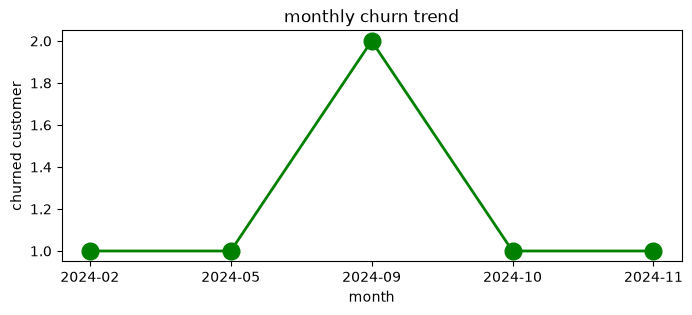

In [423]:
from matplotlib.lines import lineStyles

plt.figure(figsize= (8,3))
plt.plot(churn_trend.index.astype(str) , churn_trend.values , color='green' , marker= 'o', linewidth= 2 , markersize= 12  )

plt.xlabel('month')
plt.ylabel('churned customer')
plt.title('monthly churn trend')
plt.show()

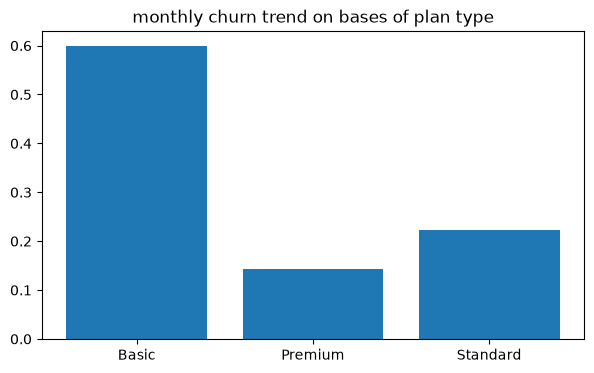

In [424]:
## churn by plan type

churn_plan= df_copy.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize= (7,4))
plt.bar(churn_plan.index.astype(str) , churn_plan.values , )

plt.title('monthly churn trend on bases of plan type')
plt.show()

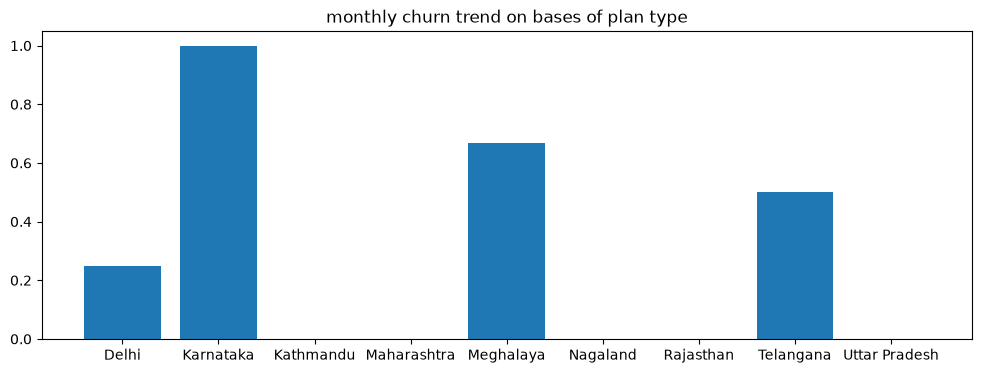

In [425]:
##3 churn by states

churn_plan= df_copy.groupby('state')['churn_flag'].mean()

plt.figure(figsize= (12,4))
plt.bar(churn_plan.index.astype(str) , churn_plan.values , )

plt.title('monthly churn trend on bases of plan type')
plt.show()

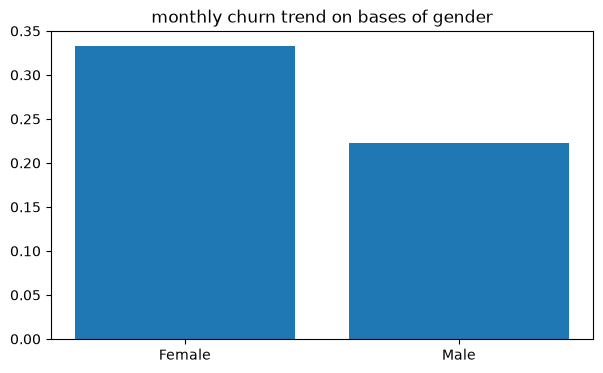

In [426]:
churn_plan= df_copy.groupby('gender')['churn_flag'].mean()

plt.figure(figsize= (7,4))
plt.bar(churn_plan.index.astype(str) , churn_plan.values , )

plt.title('monthly churn trend on bases of gender')
plt.show()

In [427]:
#3 encoding - convert str to numeric value

df_copy.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [428]:
# ## this is wrong method of encoding because numbers are not assigned on base of priority


# df_encoded=df_copy[['plan_type', 'contract_type', 'churn_score' , 'churn_flag',  'churn_risk' , 'escalations']].head()

# categorical_col = ['plan_type', 'contract_type','churn_risk']

# for col in categorical_col:
#     df_encoded[col] = df_encoded[col].astype('category').cat.codes


In [429]:
# df_encoded.head()

In [430]:
##3 visualization using  correlation matrix (heatmap)
## heatmap can only be used between numeric values
# sns.heatmap(df_encoded.corr() , annot=True)



<Axes: >

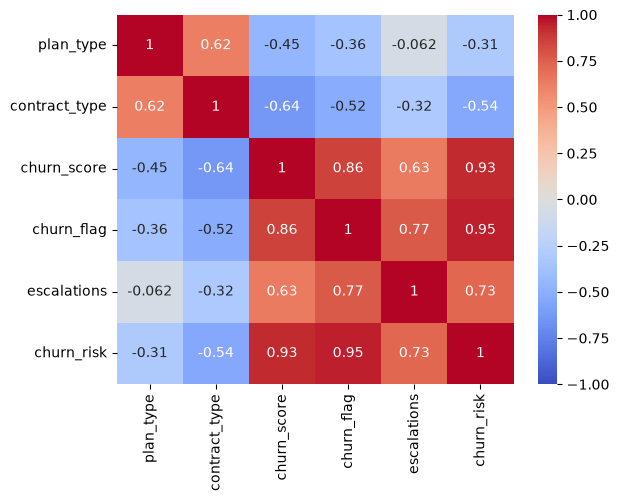

In [431]:
## corect method on encoding on bases on priority


df_encoded = df[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'escalations']].copy()

df_encoded['plan_type'] = df_encoded['plan_type'].map({
    'Basic': 0, 'Standard': 1, 'Premium': 2
})
df_encoded['contract_type'] = df_encoded['contract_type'].map({
    'Monthly': 0, 'Annual': 1
})

df_encoded['escalations'] = df['escalations'].replace({'Y': 1, 'N': 0}).fillna(0).astype(int)

df_encoded['churn_risk'] = np.where(
    df['churn_score'] >= 70, 2,
    np.where(df['churn_score'] >= 50, 1, 0)
)

sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [432]:
df_copy[['plan_type', 'contract_type', 'churn_score' , 'churn_flag',  'churn_risk' , 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [433]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


In [434]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', ' customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'age', 'churn_risk'],
      dtype='str')

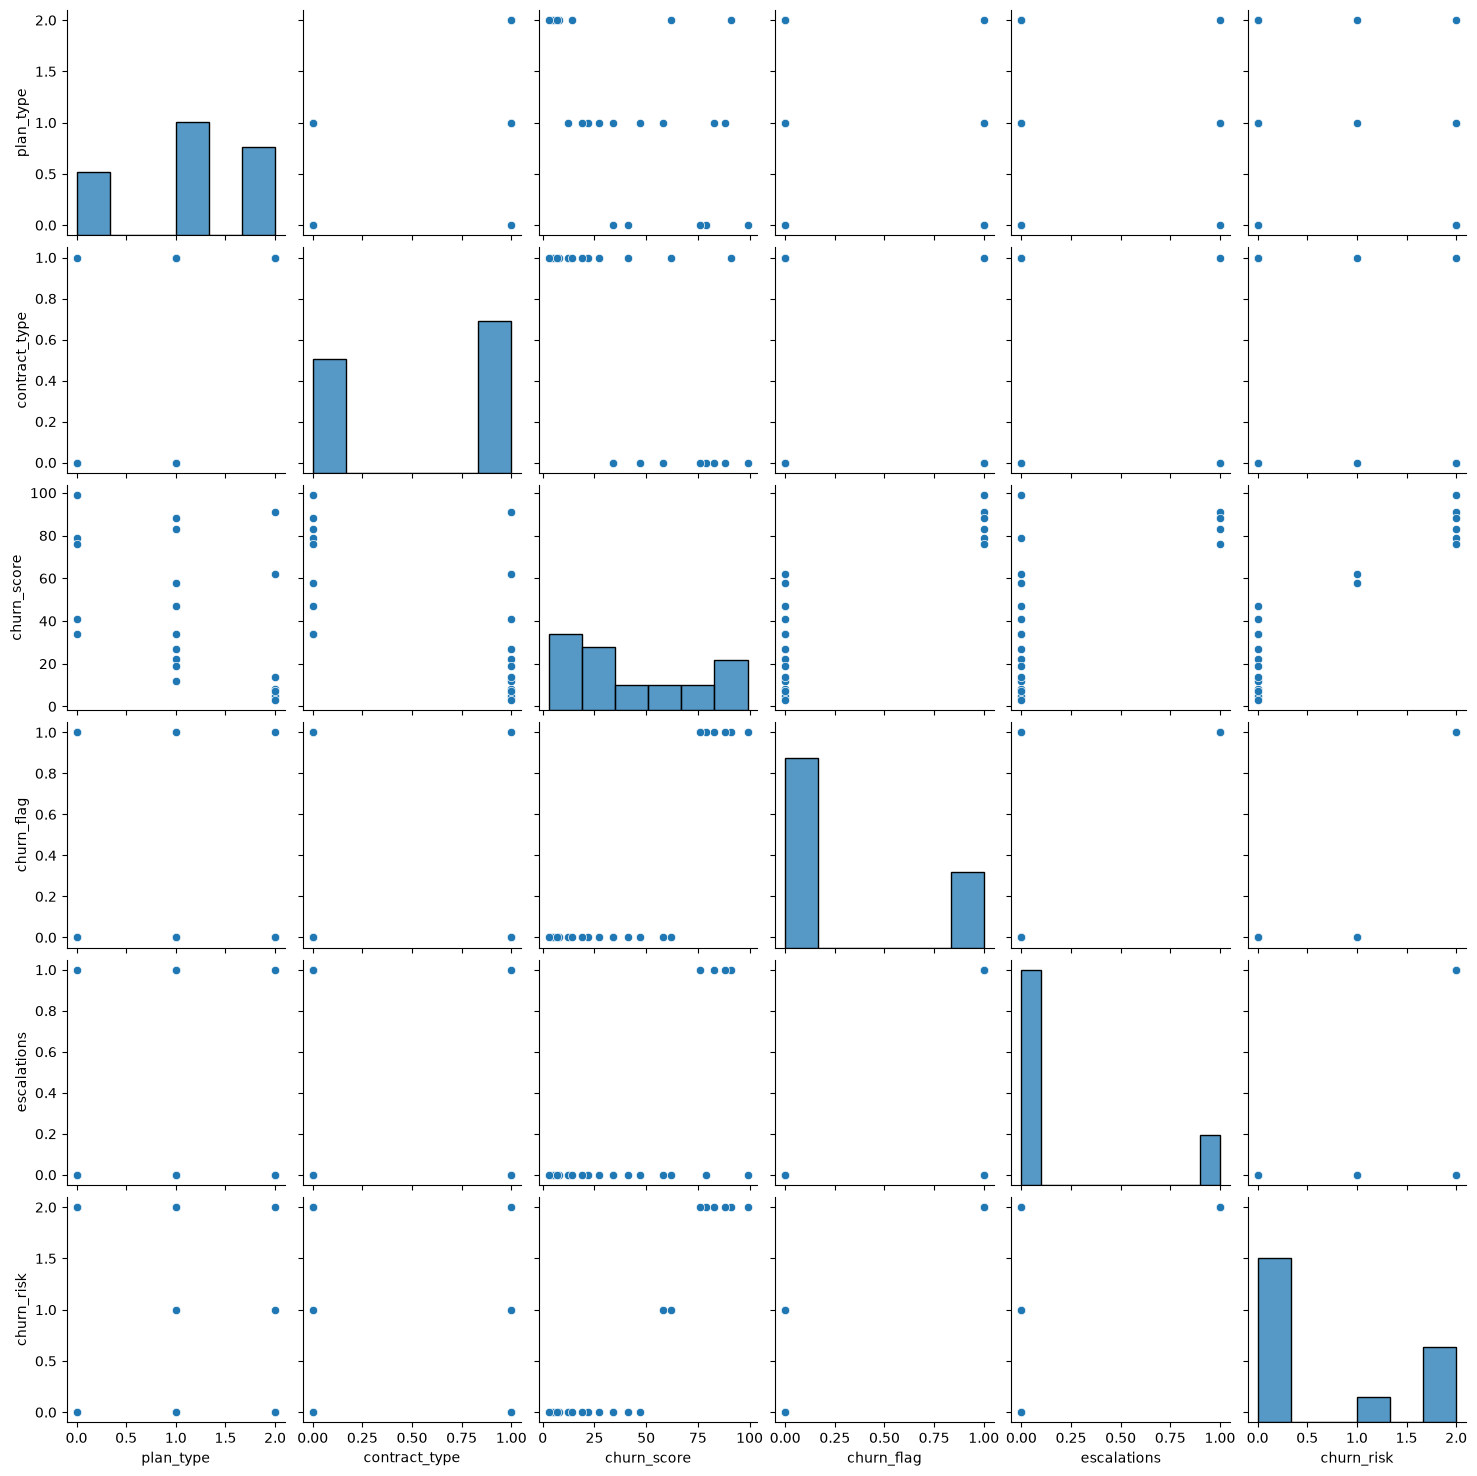

In [435]:
## pairplot   relationship in dataset

sns.pairplot(df_encoded)

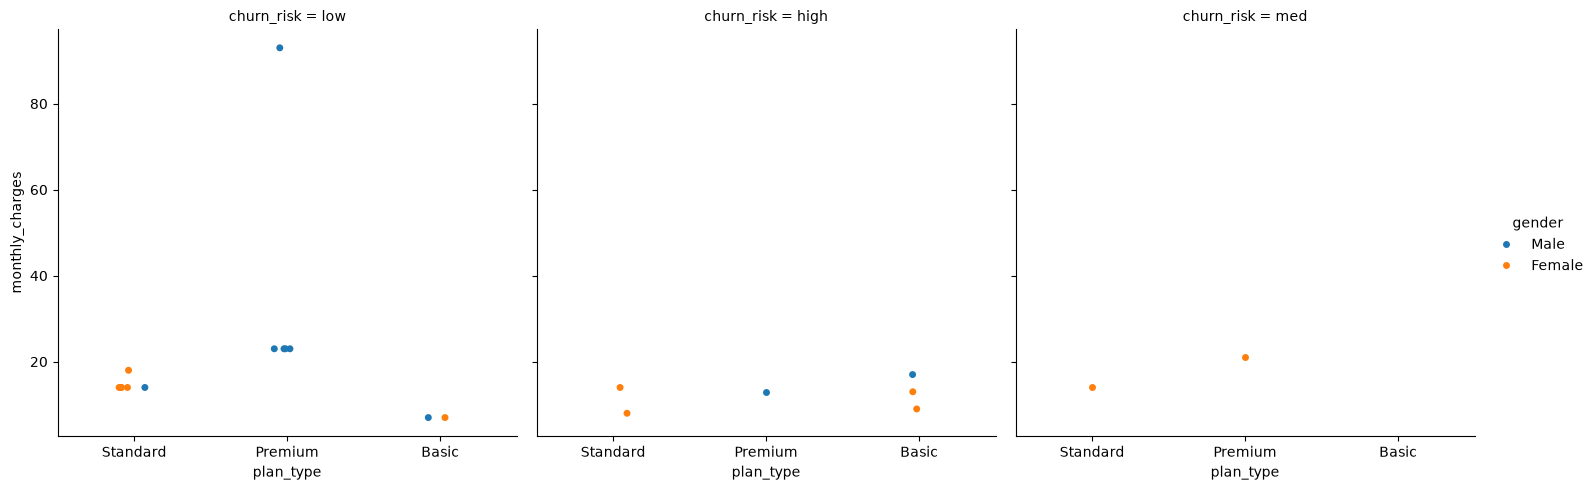

In [436]:
## facegrid plot or catplot (multi dimension comparison)

sns.catplot(data=df_copy,
x='plan_type',
y='monthly_charges',
hue='gender',
col= 'churn_risk'
)

In [437]:
## pivot table 
pd.pivot_table(
df_copy,
values= 'churn_flag',
index='plan_type',
aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [438]:
## pivot table 
pd.pivot_table(
df_copy,
index='plan_type',
values= ['churn_flag','monthly_charges','customerid'],
aggfunc={
    'churn_flag':'mean',
    'monthly_charges':'sum',
    'customerid':'nunique'
}
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# working with sql in python (pandas)


In [441]:
conn = sqlite3.connect('test_database.sqlite')

In [ ]:
# table details 
conn.execute()